This notebook analyzes the impact of the COVID-19 pandemic globally. And answer the following questions:
 1 Which countries had the highest infection and death rates?
 2. How did government responses (lockdowns) affect case growth?
  3. What was the mortality rate trend over time? 
  4. Can we predict future outbreaks using historical data? 
  5. How did vaccination rates influence case declines? 

In [2]:
#Import important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#import covid'19 dataset
covid_data = pd.read_csv("Desktop/Data Analysis class/Python-class/worldometer_coronavirus_daily_data.csv", parse_dates=['date'])
vac_data = pd.read_csv("Desktop/Data Analysis class/Python-class/country_vaccinations.csv", parse_dates = ['date'])

In [12]:
covid_data.head(5)

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-02-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-02-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-02-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-02-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-02-19,Afghanistan,0.0,NaN,0.0,0.0,NaN


In [4]:
#remove NAN from dataset
covid_data.dropna(subset=['daily_new_cases', 'daily_new_deaths', 'active_cases'], inplace=True)

In [6]:
covid_data.describe()
print(covid_data.isna().sum()) #to check for mising data

date                       0
country                    0
cumulative_total_cases     0
daily_new_cases            0
active_cases               0
cumulative_total_deaths    0
daily_new_deaths           0
dtype: int64


In [17]:
covid_data.head(5)

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
10,2020-02-25,Afghanistan,1.0,0.0,1.0,0.0,0.0
11,2020-02-26,Afghanistan,1.0,0.0,1.0,0.0,0.0
12,2020-02-27,Afghanistan,1.0,0.0,1.0,0.0,0.0
13,2020-02-28,Afghanistan,1.0,0.0,1.0,0.0,0.0
14,2020-02-29,Afghanistan,1.0,0.0,1.0,0.0,0.0


In [13]:
vac_data.head(5)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"BBIBP-CorV, Oxford/AstraZeneca, Pfizer/BioNTech",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"BBIBP-CorV, Oxford/AstraZeneca, Pfizer/BioNTech",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"BBIBP-CorV, Oxford/AstraZeneca, Pfizer/BioNTech",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"BBIBP-CorV, Oxford/AstraZeneca, Pfizer/BioNTech",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"BBIBP-CorV, Oxford/AstraZeneca, Pfizer/BioNTech",World Health Organization,https://covid19.who.int/


In [23]:
print(vac_data.isna().sum())

country                                    0
iso_code                                   0
date                                       0
total_vaccinations                     12848
people_vaccinated                      13674
people_fully_vaccinated                16407
daily_vaccinations_raw                 15683
daily_vaccinations                       241
total_vaccinations_per_hundred         12848
people_vaccinated_per_hundred          13674
people_fully_vaccinated_per_hundred    16407
daily_vaccinations_per_million           241
vaccines                                   0
source_name                                0
source_website                             0
dtype: int64


In [5]:
#countries with highest(latest) infection
latest = covid_data[covid_data['date'] == covid_data['date'].max()]
latest_top_infections = latest.sort_values('cumulative_total_cases', ascending=False).head(10)


In [29]:
print(latest_top_infections)

             date  country  cumulative_total_cases  daily_new_cases  \
177406 2022-05-14      USA              84209473.0          26740.0   
77923  2022-05-14    India              43121599.0           2487.0   
22139  2022-05-14   Brazil              30682094.0          17355.0   
59883  2022-05-14   France              29160802.0          30459.0   
64803  2022-05-14  Germany              25774509.0          40929.0   

        active_cases  cumulative_total_deaths  daily_new_deaths  
177406     1938567.0                1026646.0              55.0  
77923        17692.0                 524214.0              13.0  
22139       298772.0                 664920.0              90.0  
59883       856871.0                 147257.0               0.0  
64803      1711202.0                 137907.0              98.0  


USA, India,Brazil, France and Germany are top 5 countries with highest number of cases in the world 

In [6]:
#countries with highest(latest) death
latest_top_death = latest.sort_values('cumulative_total_deaths', ascending=False).head(10)

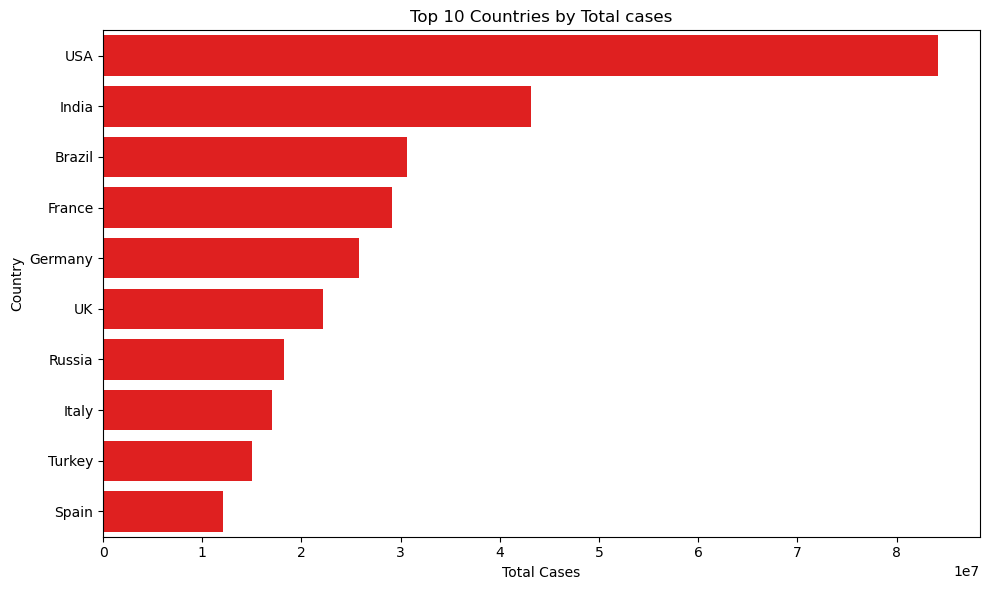

In [8]:
#top 10 countries by total infections
plt.figure(figsize=(10, 6))
sns.barplot(data=latest_top_infections, x='cumulative_total_cases', y='country', color='red')
plt.title('Top 10 Countries by Total cases')
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

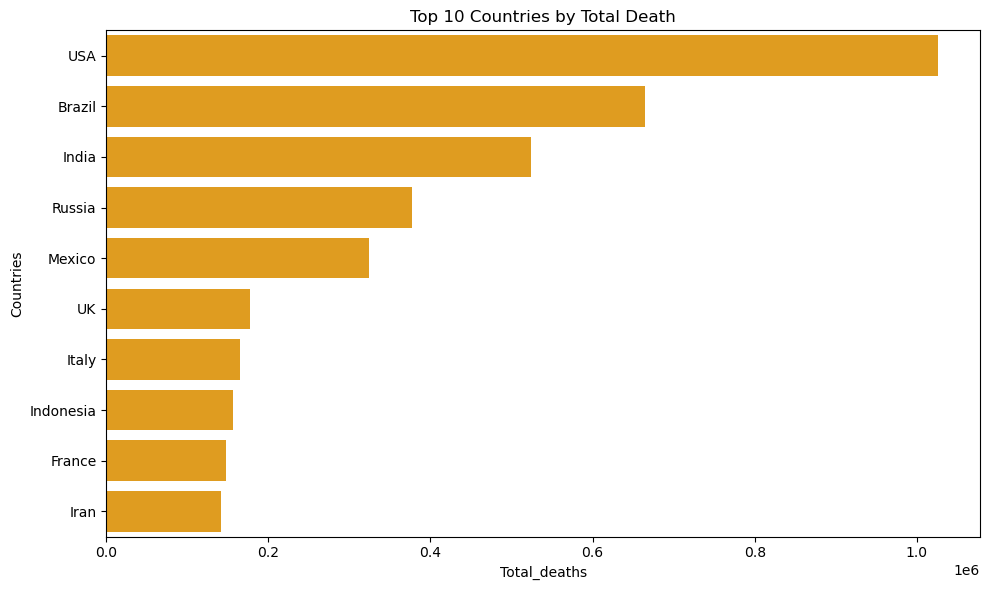

In [39]:
#top 10 countries by total death
plt.figure(figsize=(10, 6))
sns.barplot(data=latest_top_death, x='cumulative_total_deaths', y='country', color='orange')
plt.title('Top 10 Countries by Total Death')
plt.xlabel("Total_deaths")
plt.ylabel("Countries")
plt.tight_layout()
plt.show()

In [ ]:
USA,Brazil, India have the highest death recorded

In [40]:
  #3.  mortality rate trend over time?
covid_data['mortality_rate'] = (covid_data['cumulative_total_deaths'] / covid_data['cumulative_total_cases']) * 100 #percentage mortality
world_mortality = covid_data.groupby('date')['mortality_rate'].mean() #find the percentage mortality for each date

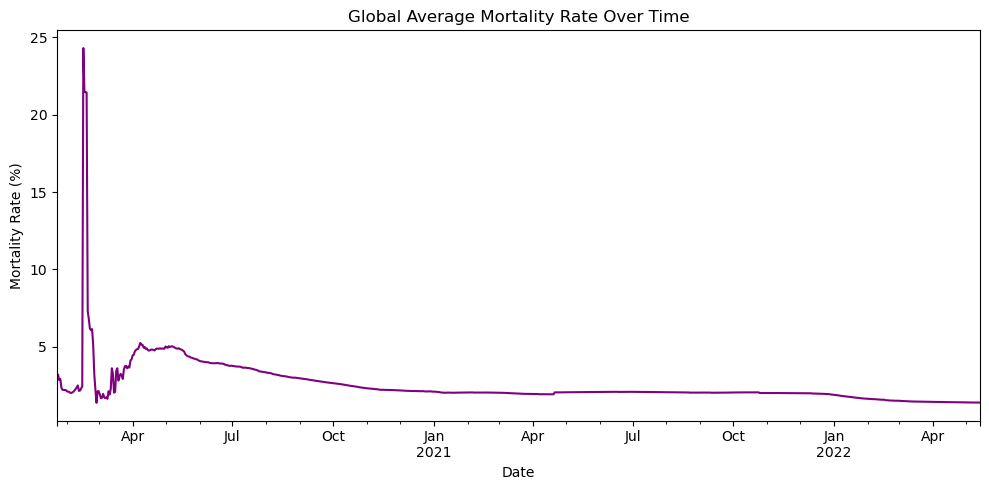

In [44]:
plt.figure(figsize=(10, 5))
world_mortality.plot(color='purple')
plt.title("Global Average Mortality Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Mortality Rate (%)")
plt.tight_layout()
plt.show()

highest mortality rate occur between feb and march 2020, but Since may 2020 there is decline in global mortality rate trend.

In [7]:
combined_df = pd.merge(covid_data, vac_data, on='date', suffixes=('_covid19', '_vaccine'))

In [47]:
combined_df.head(3)

,date,country_covid19,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths,mortality_rate,country_vaccine,iso_code,...,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,2020-12-02,Afghanistan,46980.0,263.0,8132.0,1822.0,25.0,3.878246,Norway,NOR,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Moderna, Pfizer/BioNTech",Norwegian Institute of Public Health,https://www.fhi.no/sv/vaksine/koronavaksinasjo...
1,2020-12-03,Afghanistan,47258.0,278.0,8115.0,1841.0,19.0,3.895637,Norway,NOR,...,NaN,0.0,0.0,0.0,0.0,NaN,0.0,"Moderna, Pfizer/BioNTech",Norwegian Institute of Public Health,https://www.fhi.no/sv/vaksine/koronavaksinasjo...
2,2020-12-04,Afghanistan,47388.0,130.0,8194.0,1847.0,6.0,3.897611,Latvia,LVA,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",National Health Service,https://data.gov.lv/dati/eng/dataset/covid19-v...


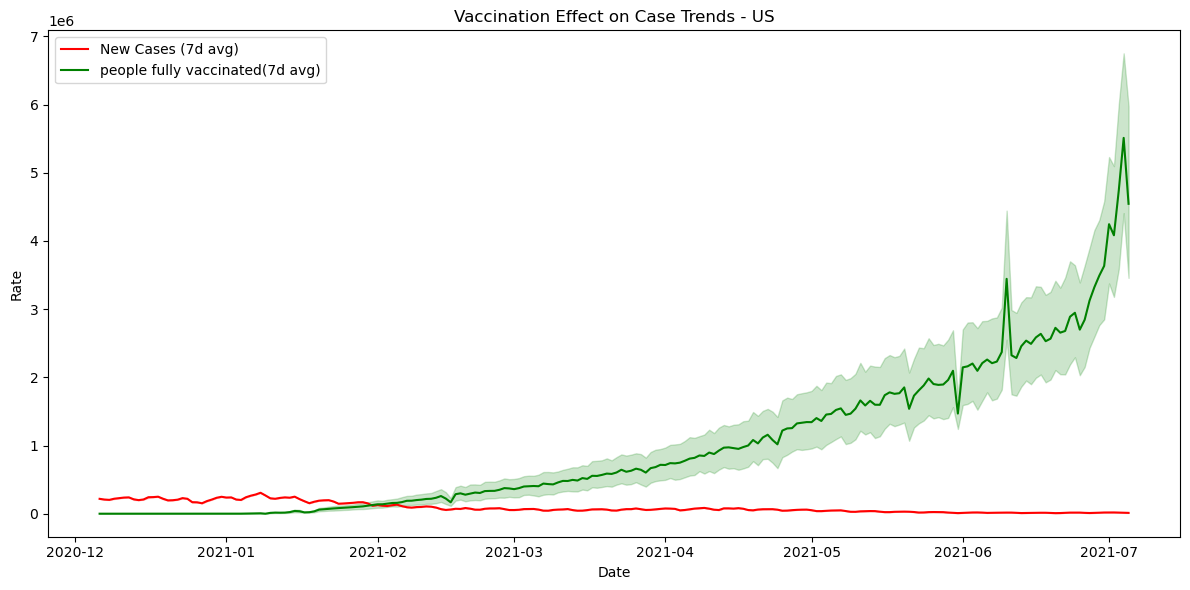

In [56]:
# Vaccination Rate vs Case Decline in USA
vacc_data = combined_df[combined_df['country_covid19'] == "USA"].copy()
vacc_data['rolling_cases'] = vacc_data['daily_new_cases'].rolling(window=7).mean()
vacc_data['rolling_vacc'] = vacc_data['people_fully_vaccinated'].fillna(0).rolling(window=7).mean()
vacc_data['rolling_act'] = vacc_data['people_fully_vaccinated'].fillna(0).rolling(window=7).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=vacc_data, x='date', y='rolling_cases', label='New Cases (7d avg)', color='red')
sns.lineplot(data=vacc_data, x='date', y='rolling_vacc', label='people fully vaccinated(7d avg)', color='green')
plt.title("Vaccination Effect on Case Trends - US")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()

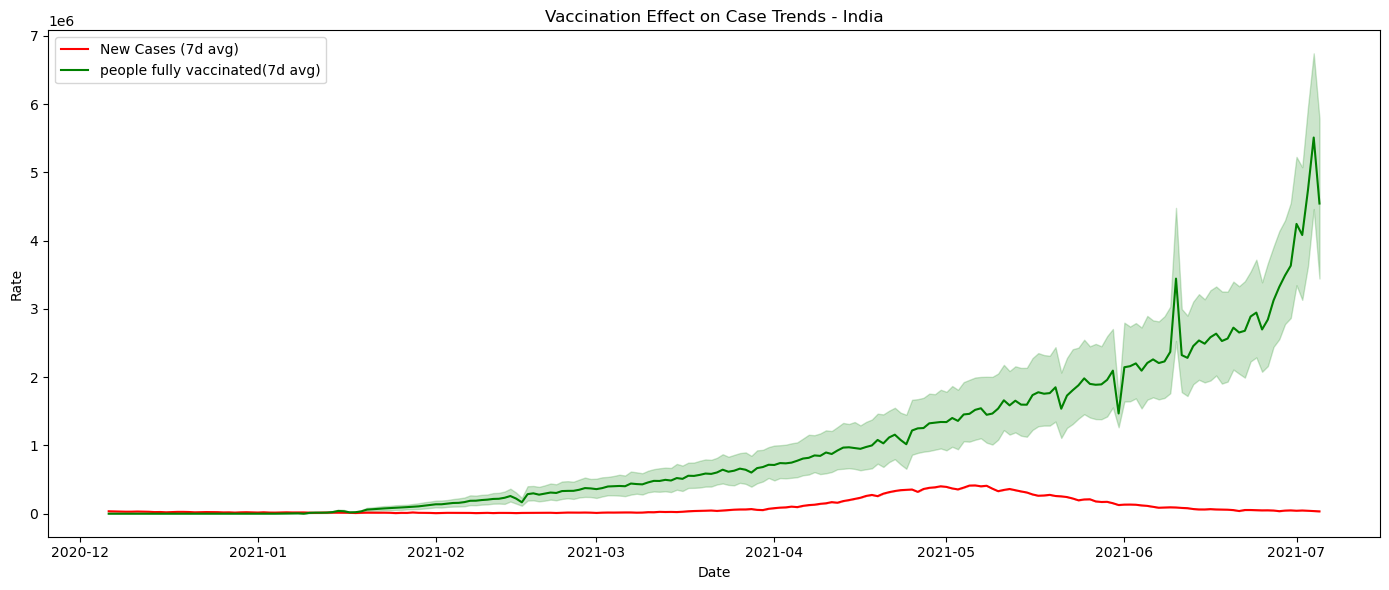

In [20]:
# Vaccination Rate vs Case Decline in India
vacci_data = combined_df[combined_df['country_covid19'] == "India"].copy()
vacci_data['rolling_cases'] = vacci_data['daily_new_cases'].rolling(window=7).mean()
vacci_data['rolling_vacc'] = vacci_data['people_fully_vaccinated'].fillna(0).rolling(window=7).mean()

plt.figure(figsize=(14, 6))
sns.lineplot(data=vacci_data, x='date', y='rolling_cases', label='New Cases (7d avg)', color='red')
sns.lineplot(data=vacci_data, x='date', y='rolling_vacc', label='people fully vaccinated(7d avg)', color='green')
#sns.lineplot(data=vacci_data, x='date', y='rolling_vacc', label=
plt.title("Vaccination Effect on Case Trends - India")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
The more the people vaccinatet the less the infection: covid'19 infection decreases with increase in number of people 

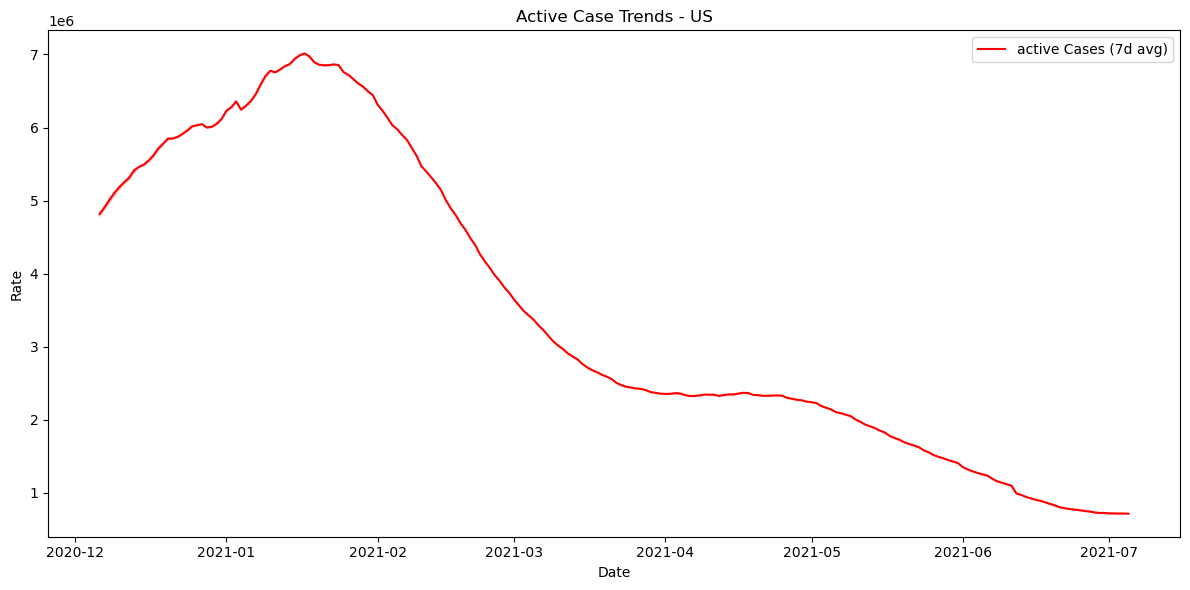

In [23]:
#Active case trend in US
vacc_data = combined_df[combined_df['country_covid19'] == "USA"].copy()
vacc_data['rolling_vacc'] = vacc_data['people_fully_vaccinated'].fillna(0).rolling(window=7).mean()
vacc_data['rolling_act'] = vacc_data['active_cases'].fillna(0).rolling(window=7).mean()


plt.figure(figsize=(12, 6))
sns.lineplot(data=vacc_data, x='date', y='rolling_act', label='active Cases (7d avg)', color='red')
#sns.lineplot(data=vacc_data, x='date', y='rolling_vacc', label='people fully vaccinated(7d avg)', color='green')
plt.title("Active Case Trends - US")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("""
SUMMARY INSIGHTS:
- The US and India experienced the highest total case report, while most death occur at  US and Bazil.
-
- Global mortality rate declined over time since April 2021, possibly due to improved treatment and vaccination.
- 
- Gnenerally, The higher the vaccination, the lower the new case  reported.
- Report from US show  high recovery rates over time(decline in active cases); further investigation is needed to uncover the reason why.
""")